In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

C:\Users\abhia\AppData\Local\Temp\ipykernel_19080\3975489523.py:46: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')



📊 MODEL PERFORMANCE
MAE : 17.06772930190892
RMSE: 22.611561231087297
R2  : 0.7404032530754072


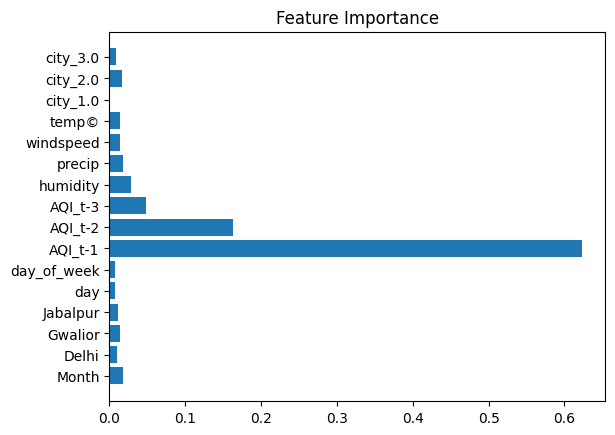


🔁 Cross Validation:
Fold 1 RMSE: 64.03023473220959
Fold 2 RMSE: 40.61746332725997
Fold 3 RMSE: 29.661915653941346
Fold 4 RMSE: 18.405906310977514
Fold 5 RMSE: 23.28753314224615


In [7]:
# ================================
# 🔥 FINAL CORRECTED AQI XGBOOST PIPELINE
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

# ================================
# 1. LOAD DATA
# ================================
df = pd.read_excel("final_dataset.xlsx")

# ================================
# 2. CLEAN DATA
# ================================
# Remove duplicate/unwanted columns
df = df.drop(columns=['Unnamed: 0', 'city.1'], errors='ignore')

# Ensure correct column name
if 'Average' in df.columns:
    df = df.rename(columns={'Average': 'AQI'})

# ================================
# 3. HANDLE CITY (IMPORTANT)
# ================================
# If city is text → convert to one-hot
if 'city' in df.columns:
    df = pd.get_dummies(df, columns=['city'])

# ================================
# 4. HANDLE MISSING VALUES (PROPER WAY)
# ================================
# Drop rows where lag features are NaN (VERY IMPORTANT)
lag_cols = ['AQI_t-1', 'AQI_t-2', 'AQI_t-3']
existing_lags = [col for col in lag_cols if col in df.columns]

if len(existing_lags) > 0:
    df = df.dropna(subset=existing_lags)

# Then fill remaining values
df = df.fillna(method='ffill').fillna(method='bfill')

# ================================
# 5. FEATURE ENGINEERING
# ================================
if 'temp' in df.columns and 'humidity' in df.columns:
    df['temp_humidity'] = df['temp'] * df['humidity']

if 'windspeed' in df.columns and 'temp' in df.columns:
    df['wind_temp'] = df['windspeed'] * df['temp']

# ================================
# 6. FEATURES & TARGET
# ================================
X = df.drop(columns=['AQI'])
y = df['AQI']

# ================================
# 7. TRAIN-TEST SPLIT (TIME SERIES)
# ================================
split = int(0.8 * len(df))

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# ================================
# 8. MODEL (IMPROVED)
# ================================
model = XGBRegressor(
    n_estimators=800,          # increased
    learning_rate=0.03,        # smaller = better learning
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.5,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42
)

# ================================
# 9. TRAIN
# ================================
model.fit(X_train, y_train)

# ================================
# 10. PREDICT
# ================================
y_pred = model.predict(X_test)

# ================================
# 11. EVALUATE
# ================================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 MODEL PERFORMANCE")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

# ================================
# 12. FEATURE IMPORTANCE
# ================================
importance = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

# ================================
# 13. TIME SERIES CROSS VALIDATION
# ================================
print("\n🔁 Cross Validation:")

tscv = TimeSeriesSplit(n_splits=5)

for i, (train_index, test_index) in enumerate(tscv.split(X)):
    X_tr, X_te = X.iloc[train_index], X.iloc[test_index]
    y_tr, y_te = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    rmse_fold = np.sqrt(mean_squared_error(y_te, preds))
    print(f"Fold {i+1} RMSE:", rmse_fold)

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Better AQI category (REDUCED CLASSES)
def aqi_category(aqi):
    if aqi <= 100:
        return 0   # Good + Satisfactory
    elif aqi <= 200:
        return 1   # Moderate
    elif aqi <= 300:
        return 2   # Poor
    else:
        return 3   # Very Poor + Severe

# Convert actual and predicted
y_test_cat = [aqi_category(x) for x in y_test]
y_pred_cat = [aqi_category(x) for x in y_pred]

# Metrics
acc = accuracy_score(y_test_cat, y_pred_cat)
prec = precision_score(y_test_cat, y_pred_cat, average='weighted')
rec = recall_score(y_test_cat, y_pred_cat, average='weighted')

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)

print("\nClassification Report:\n")
print(classification_report(y_test_cat, y_pred_cat))

Accuracy : 0.8387096774193549
Precision: 0.8636178614711917
Recall   : 0.8387096774193549

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.85      0.90       156
           1       0.64      0.84      0.72        55
           2       0.50      0.50      0.50         6

    accuracy                           0.84       217
   macro avg       0.70      0.73      0.71       217
weighted avg       0.86      0.84      0.85       217



In [5]:
df.isnull().sum()

AQI            0
Month          0
Delhi          0
Gwalior        0
Jabalpur       0
day            0
day_of_week    0
city           0
AQI_t-1        0
AQI_t-2        0
AQI_t-3        0
humidity       0
precip         0
windspeed      0
temp©          0
city.1         0
dtype: int64